In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import Logistic
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [155]:
d = pd.read_csv('car evaluation_with_HW.csv')
d.head(5)

,vhigh,vhigh.1,2,2.1,small,med,unacc
0,vhigh,vhigh,2,2,small,high,unacc
1,vhigh,vhigh,2,2,med,low,unacc
2,vhigh,vhigh,2,2,med,med,unacc
3,vhigh,vhigh,2,2,med,high,unacc
4,vhigh,vhigh,2,2,big,low,unacc


In [163]:
d['unacc'].unique()

<StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str

In [156]:
print(d.duplicated().sum())
print(d.isna().sum())

0
vhigh      0
vhigh.1    0
2          0
2.1        0
small      0
med        0
unacc      0
dtype: int64


In [157]:
x = d.drop("unacc", axis=1)
y = d['unacc']
x = pd.get_dummies(x)
#y = pd.get_dummies(y)

In [158]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=42, test_size=0.2)

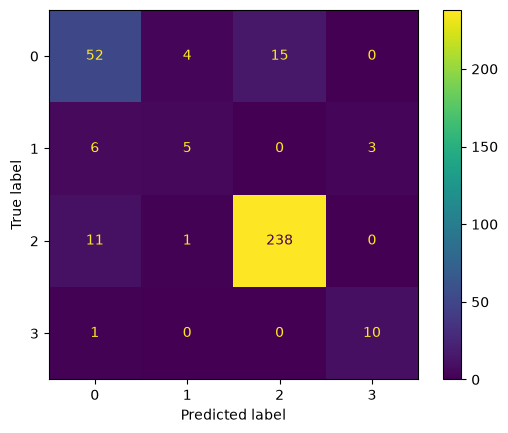

In [159]:
lr = LogisticRegression(max_iter=900)
lr.fit(x_train, y_train)
pred = lr.predict(x_test)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

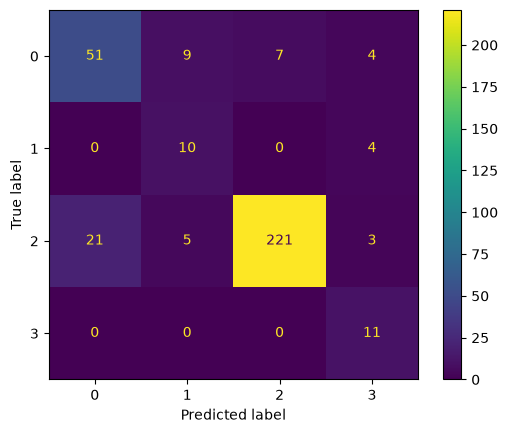

In [160]:
sm = SMOTE()
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

lr.fit(x_train_sm, y_train_sm)
predsm = lr.predict(x_test)
cm = confusion_matrix(y_test, predsm)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [161]:
print(classification_report(y_test, pred), '\n')
print(classification_report(y_test, predsm))

              precision    recall  f1-score   support

         acc       0.74      0.73      0.74        71
        good       0.50      0.36      0.42        14
       unacc       0.94      0.95      0.95       250
       vgood       0.77      0.91      0.83        11

    accuracy                           0.88       346
   macro avg       0.74      0.74      0.73       346
weighted avg       0.88      0.88      0.88       346
 

              precision    recall  f1-score   support

         acc       0.71      0.72      0.71        71
        good       0.42      0.71      0.53        14
       unacc       0.97      0.88      0.92       250
       vgood       0.50      1.00      0.67        11

    accuracy                           0.85       346
   macro avg       0.65      0.83      0.71       346
weighted avg       0.88      0.85      0.86       346

